<h1>RFM calculation</h1>
<h2>Recency - Frequency - Monetary</h2>

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

<h2>Load Cleaned Transaction</h2>

In [3]:
DATA_PATH = (
    PROCESSED_DATA_DIR /
    "online_retail_cleaned.csv"
)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["InvoiceDate"]
)

print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

Rows: 1,010,535
Columns: 24


<h2>Important Decision: Anonymous Customers</h2>
<p>We decided not to delete anonymous transactions. But RFM requires a customer identifier.

Therefore: 

Overall sales analysis -> Anonymous + identified customers

Customer analytics -> Identified customers only
</p>

In [4]:
rfm_transactions = df[
    df["CustomerID"].notna()
].copy()

print(
    f"Total transactions: {len(df):,}"
)

print(
    f"Identified-customer transactions: "
    f"{len(rfm_transactions):,}"
)

print(
    f"Anonymous transactions excluded from RFM: "
    f"{df['CustomerID'].isna().sum():,}"
)

Total transactions: 1,010,535
Identified-customer transactions: 779,495
Anonymous transactions excluded from RFM: 231,040


<h2>Make Sure We're Using Sales Only</h2>

In [5]:
print(
    "Negative quantities:",
    (rfm_transactions["Quantity"] < 0).sum()
)

Negative quantities: 0


<h2>Understand the Customer Dataset</h2>

In [6]:
rfm_transactions[
    [
        "CustomerID",
        "Invoice",
        "InvoiceDate",
        "Quantity",
        "UnitPrice",
        "TotalPrice"
    ]
].head(10)

,CustomerID,Invoice,InvoiceDate,Quantity,UnitPrice,TotalPrice
0,"13,085.00",489434,2009-12-01 07:45:00,12,6.95,83.40
1,"13,085.00",489434,2009-12-01 07:45:00,12,6.75,81.00
2,"13,085.00",489434,2009-12-01 07:45:00,12,6.75,81.00
3,"13,085.00",489434,2009-12-01 07:45:00,48,2.10,100.80
4,"13,085.00",489434,2009-12-01 07:45:00,24,1.25,30.00
5,"13,085.00",489434,2009-12-01 07:45:00,24,1.65,39.60
6,"13,085.00",489434,2009-12-01 07:45:00,24,1.25,30.00
7,"13,085.00",489434,2009-12-01 07:45:00,10,5.95,59.50
8,"13,085.00",489435,2009-12-01 07:46:00,12,2.55,30.60
9,"13,085.00",489435,2009-12-01 07:46:00,12,3.75,45.00


<h2>Determine Analysis Date</h2>
<p>A common approach is:

Analysis Date = latest transaction date + 1 day

This means the most recent purchaser receives:

Recency = 1

rather than 0.</p>

In [7]:
analysis_date = (
    rfm_transactions["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

print("Latest transaction:")
print(rfm_transactions["InvoiceDate"].max())

print("\nAnalysis date:")
print(analysis_date)

Latest transaction:
2011-12-09 12:50:00

Analysis date:
2011-12-10 12:50:00


<h2>Calculate RFM</h2>

In [8]:
rfm = (
    rfm_transactions
    .groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (
                analysis_date - x.max()
            ).days
        ),

        Frequency=(
            "Invoice",
            "nunique"
        ),

        Monetary=(
            "TotalPrice",
            "sum"
        )
    )
    .reset_index()
)

<h2>Validate RFM</h2>

In [9]:
print(
    f"Customers: {len(rfm):,}"
)

print(
    f"Minimum recency: "
    f"{rfm['Recency'].min()} days"
)

print(
    f"Maximum recency: "
    f"{rfm['Recency'].max()} days"
)

print(
    f"Minimum frequency: "
    f"{rfm['Frequency'].min()}"
)

print(
    f"Maximum frequency: "
    f"{rfm['Frequency'].max()}"
)

print(
    f"Minimum monetary: "
    f"£{rfm['Monetary'].min():,.2f}"
)

print(
    f"Maximum monetary: "
    f"£{rfm['Monetary'].max():,.2f}"
)

Customers: 5,881
Minimum recency: 1 days
Maximum recency: 739 days
Minimum frequency: 1
Maximum frequency: 398
Minimum monetary: £0.00
Maximum monetary: £580,987.04


<h2>RFM Descriptive Statistics</h2>

In [10]:
rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
].describe()

,Recency,Frequency,Monetary
count,"5,881.00","5,881.00","5,881.00"
mean,201.46,6.29,"2,954.40"
std,209.47,13.01,"14,437.32"
min,1.00,1.00,0.00
25%,26.00,1.00,341.90
50%,96.00,3.00,865.60
75%,380.00,7.00,"2,247.72"
max,739.00,398.00,"580,987.04"


<h2>RFM Distributions</h2>

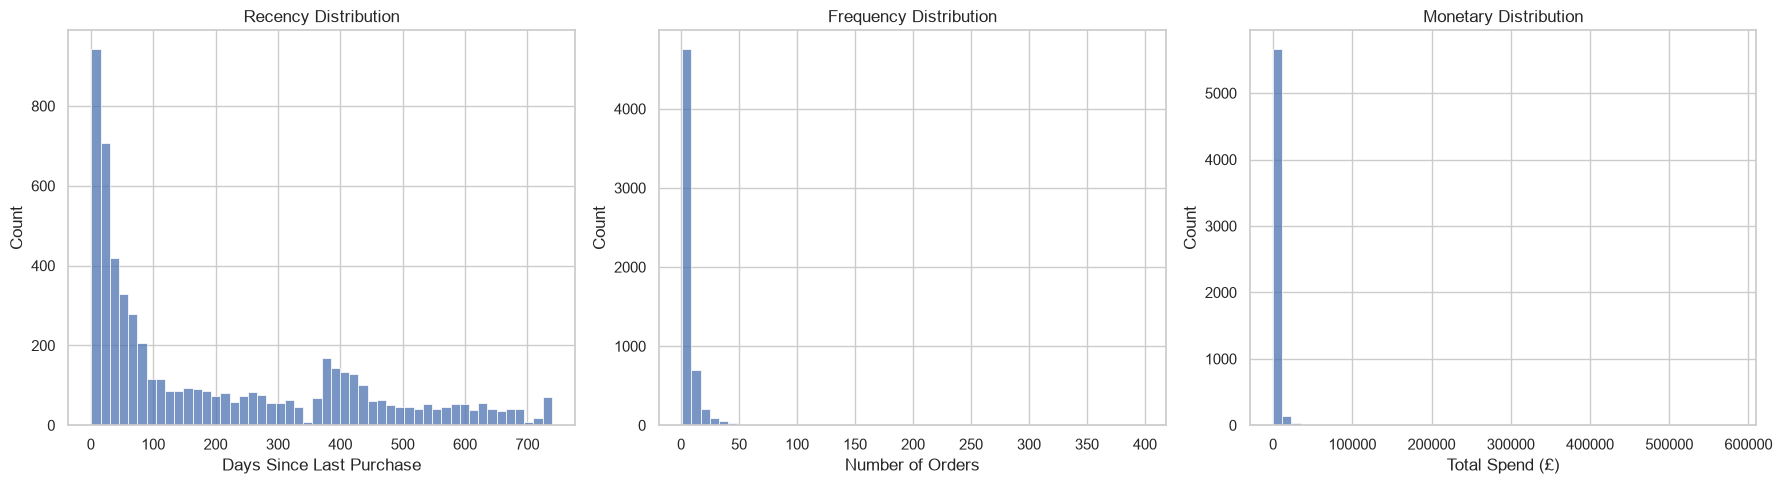

In [11]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

sns.histplot(
    rfm["Recency"],
    bins=50,
    ax=axes[0]
)

axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days Since Last Purchase")

sns.histplot(
    rfm["Frequency"],
    bins=50,
    ax=axes[1]
)

axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Orders")

sns.histplot(
    rfm["Monetary"],
    bins=50,
    ax=axes[2]
)

axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Total Spend (£)")

plt.tight_layout()
plt.show()

<h2>RFM Boxplots</h2>

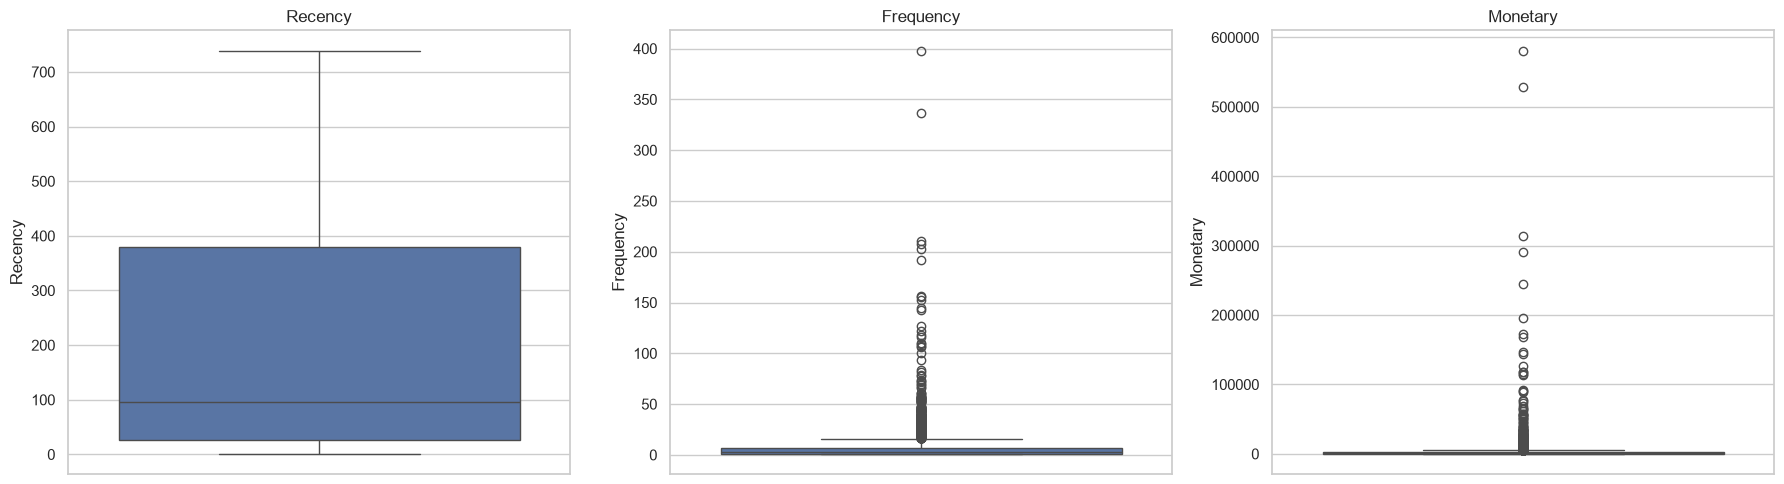

In [12]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

sns.boxplot(
    y=rfm["Recency"],
    ax=axes[0]
)

axes[0].set_title("Recency")

sns.boxplot(
    y=rfm["Frequency"],
    ax=axes[1]
)

axes[1].set_title("Frequency")

sns.boxplot(
    y=rfm["Monetary"],
    ax=axes[2]
)

axes[2].set_title("Monetary")

plt.tight_layout()
plt.show()

<h2>Inspect Top Customers</h2>
<p>Top spenders</p>

In [13]:
rfm.sort_values(
    "Monetary",
    ascending=False
).head(20)

,CustomerID,Recency,Frequency,Monetary
5695,"18,102.00",1,145,"580,987.04"
2279,"14,646.00",2,152,"528,602.52"
1791,"14,156.00",10,156,"313,437.62"
2541,"14,911.00",1,398,"291,420.81"
5053,"17,450.00",8,51,"244,784.25"
1332,"13,694.00",4,143,"195,640.69"
5112,"17,511.00",3,60,"172,132.87"
4064,"16,446.00",1,2,"168,472.50"
4298,"16,684.00",4,55,"147,142.77"
68,"12,415.00",24,28,"144,458.37"


<p>Most frequent customers</p>

In [14]:
rfm.sort_values(
    "Frequency",
    ascending=False
).head(20)

,CustomerID,Recency,Frequency,Monetary
2541,"14,911.00",1,398,"291,420.81"
400,"12,748.00",1,337,"53,539.64"
5436,"17,841.00",2,211,"68,545.25"
2938,"15,311.00",1,208,"114,966.42"
739,"13,089.00",3,203,"113,416.91"
2239,"14,606.00",1,192,"29,951.37"
1791,"14,156.00",10,156,"313,437.62"
5445,"17,850.00",372,155,"51,208.87"
2279,"14,646.00",2,152,"528,602.52"
5695,"18,102.00",1,145,"580,987.04"


<p>Most recent customers</p>

In [15]:
rfm.sort_values(
    "Recency"
).head(20)

,CustomerID,Recency,Frequency,Monetary
2541,"14,911.00",1,398,"291,420.81"
917,"13,269.00",1,28,"8,537.32"
3319,"15,694.00",1,24,"9,978.48"
4240,"16,626.00",1,17,"4,413.10"
664,"13,013.00",1,29,"11,097.43"
4609,"17,001.00",1,19,"6,640.80"
171,"12,518.00",1,5,"2,056.89"
2363,"14,730.00",1,8,"1,897.57"
719,"13,069.00",1,38,"9,284.45"
5010,"17,405.00",1,3,"1,031.41"


<h2>RFM Scoring</h2>

<p>We'll use quintiles.
For: Frequency & Monetary
higher = better.
For: Recency
lower = better.
Use qcut.</p>

In [16]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"]
    .rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"]
    .rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

<p>Convert to integers:</p>

In [17]:
rfm[
    ["R_Score", "F_Score", "M_Score"]
] = rfm[
    ["R_Score", "F_Score", "M_Score"]
].astype(int)

<h2>Create Combined RFM Score</h2>

In [18]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

<h2>Numeric RFM Score</h2>

In [19]:
rfm["RFM_Total"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

In [20]:
rfm["RFM_Total"].value_counts().sort_index()

RFM_Total
3     318
4     482
5     502
6     471
7     473
8     472
9     510
10    453
11    475
12    430
13    437
14    389
15    469
Name: count, dtype: int64

<h2>Rule-Based Customer Segmentation</h2>

Now we translate RFM scores into business categories.

We'll use the following practical segmentation:

Segment	Rule:
Champions	R ≥ 4, F ≥ 4, M ≥ 4 |
Loyal Customers	R ≥ 3, F ≥ 4 |
Potential Loyalists	R ≥ 4, F 2–3 |
New Customers	R = 5, F ≤ 2 |
Big Spenders	M = 5 |
At Risk	R ≤ 2, F ≥ 3 |
Lost Customers	R = 1, F ≤ 2 |
Others	Everything else

<h2>Create Segments</h2>

In [22]:
def assign_segment(row):

    r = row["R_Score"]
    f = row["F_Score"]
    m = row["M_Score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 4:
        return "Loyal Customers"

    elif r >= 4 and f >= 2:
        return "Potential Loyalists"

    elif r == 5 and f <= 2:
        return "New Customers"

    elif m == 5:
        return "Big Spenders"

    elif r <= 2 and f >= 3:
        return "At Risk"

    elif r == 1 and f <= 2:
        return "Lost Customers"

    else:
        return "Others"

rfm["Segment"] = rfm.apply(
    assign_segment,
    axis=1
)

<h2>Check Segments</h2>

In [23]:
rfm["Segment"].value_counts()

Segment
Others                 1378
Champions              1297
Lost Customers          880
At Risk                 727
Potential Loyalists     714
Loyal Customers         701
Big Spenders            129
New Customers            55
Name: count, dtype: int64

In [24]:
segment_distribution = (
    rfm["Segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

segment_distribution

Segment
Others                23.43
Champions             22.05
Lost Customers        14.96
At Risk               12.36
Potential Loyalists   12.14
Loyal Customers       11.92
Big Spenders           2.19
New Customers          0.94
Name: proportion, dtype: float64

<h2>Visualize Customer Segments</h2>

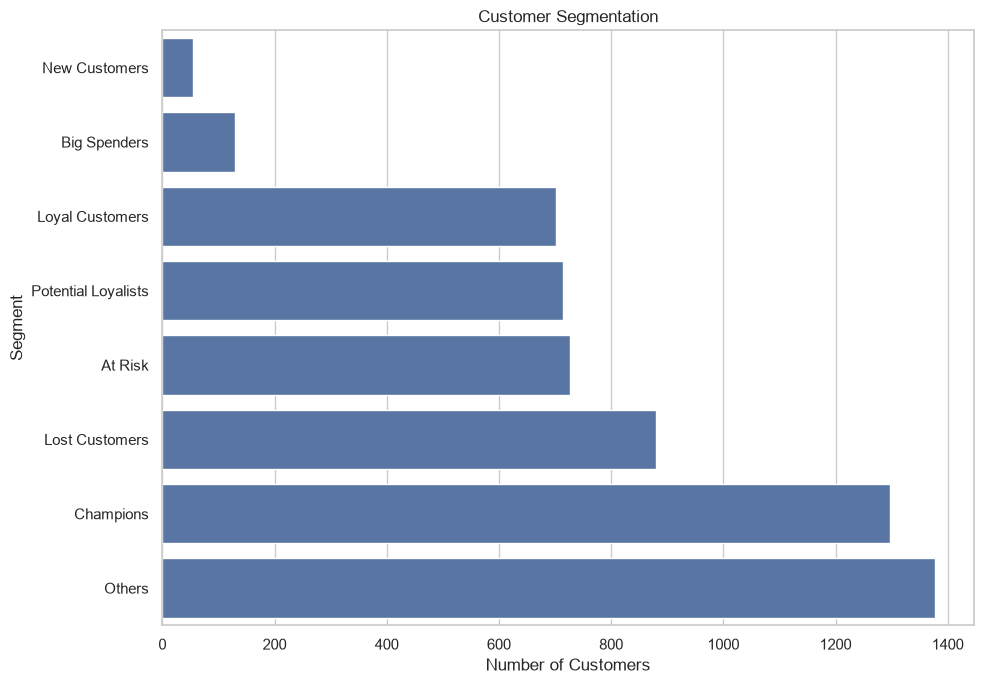

In [25]:
segment_counts = (
    rfm["Segment"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index
)

plt.title("Customer Segmentation")
plt.xlabel("Number of Customers")
plt.ylabel("Segment")

plt.tight_layout()
plt.show()

<h2>Segment Revenue</h2>

In [26]:
segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Revenue=("Monetary", "sum"),
        AvgSpend=("Monetary", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgRecency=("Recency", "mean")
    )
    .sort_values(
        "Revenue",
        ascending=False
    )
)

segment_summary

,Customers,Revenue,AvgSpend,AvgFrequency,AvgRecency
Segment,,,,,
Champions,1297,"11,859,591.49","9,143.86",17.11,19.96
Loyal Customers,701,"1,856,667.02","2,648.60",7.74,84.37
Big Spenders,129,"1,038,858.56","8,053.17",9.41,328.17
Potential Loyalists,714,"815,892.04","1,142.71",2.59,25.76
At Risk,727,"756,478.08","1,040.55",4.04,371.65
Others,1378,"720,802.42",523.08,1.63,200.25
Lost Customers,880,"307,088.32",348.96,1.20,559.43
New Customers,55,"19,426.32",353.21,1.00,10.56


<h2>Revenue by Segment</h2>

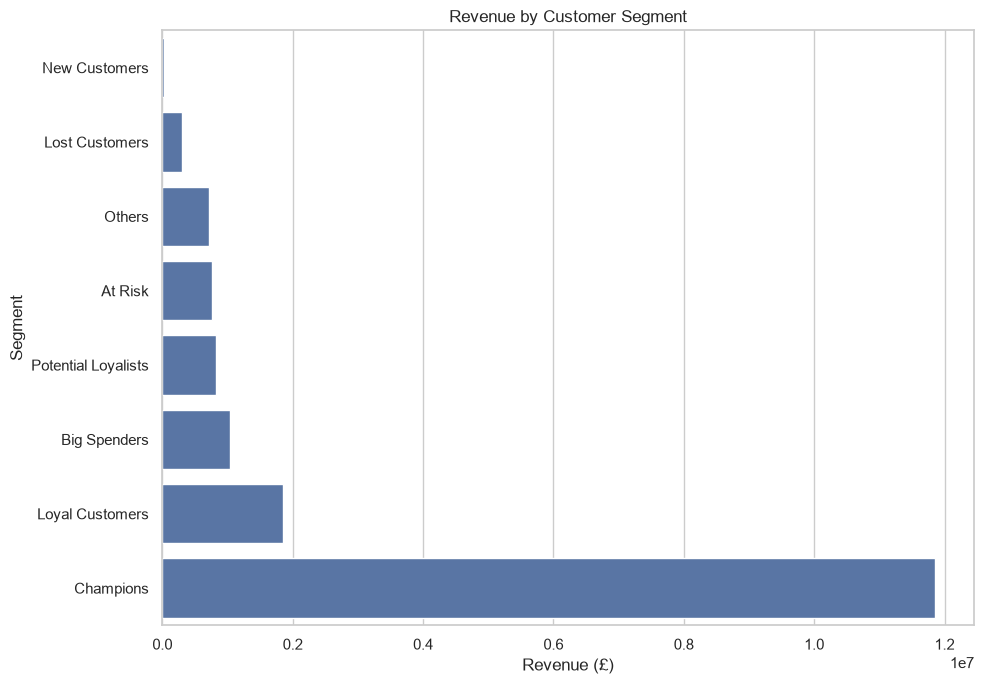

In [27]:
segment_revenue = (
    segment_summary["Revenue"]
    .sort_values()
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=segment_revenue.values,
    y=segment_revenue.index
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Revenue (£)")
plt.ylabel("Segment")

plt.tight_layout()
plt.show()

<h2>Percentage of Revenue</h2>

In [28]:
segment_summary["RevenueShare"] = (
    segment_summary["Revenue"] /
    segment_summary["Revenue"].sum() *
    100
)

segment_summary[
    [
        "Customers",
        "Revenue",
        "RevenueShare",
        "AvgSpend",
        "AvgFrequency",
        "AvgRecency"
    ]
]

,Customers,Revenue,RevenueShare,AvgSpend,AvgFrequency,AvgRecency
Segment,,,,,,
Champions,1297,"11,859,591.49",68.26,"9,143.86",17.11,19.96
Loyal Customers,701,"1,856,667.02",10.69,"2,648.60",7.74,84.37
Big Spenders,129,"1,038,858.56",5.98,"8,053.17",9.41,328.17
Potential Loyalists,714,"815,892.04",4.70,"1,142.71",2.59,25.76
At Risk,727,"756,478.08",4.35,"1,040.55",4.04,371.65
Others,1378,"720,802.42",4.15,523.08,1.63,200.25
Lost Customers,880,"307,088.32",1.77,348.96,1.20,559.43
New Customers,55,"19,426.32",0.11,353.21,1.00,10.56


<h2>Customer Count vs Revenue</h2>

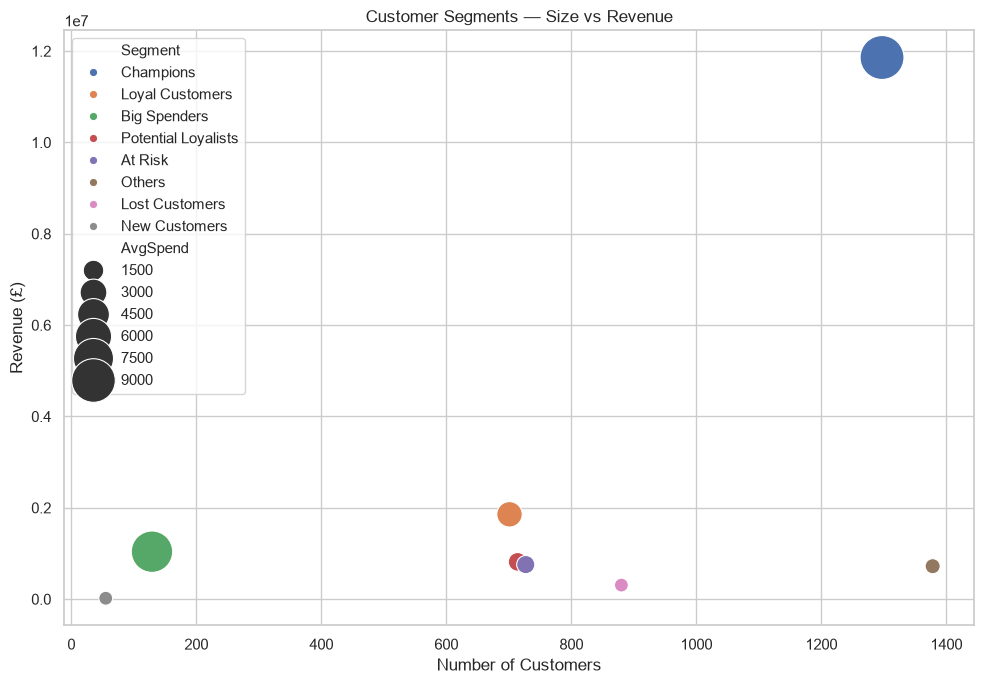

In [29]:
segment_plot = (
    segment_summary
    .reset_index()
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=segment_plot,
    x="Customers",
    y="Revenue",
    size="AvgSpend",
    hue="Segment",
    sizes=(100, 1000)
)

plt.title(
    "Customer Segments — Size vs Revenue"
)

plt.xlabel("Number of Customers")
plt.ylabel("Revenue (£)")

plt.tight_layout()
plt.show()

<h2>RFM Heatmap</h2>

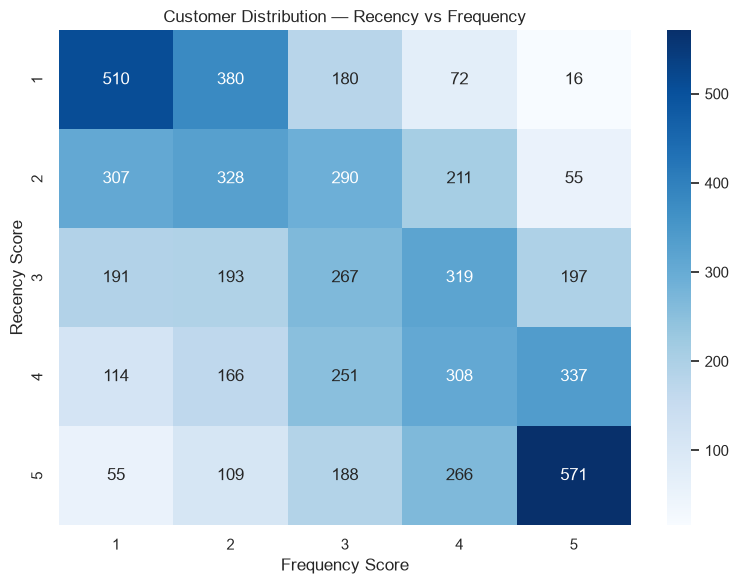

In [30]:
rfm_score_matrix = pd.crosstab(
    rfm["R_Score"],
    rfm["F_Score"]
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    rfm_score_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Customer Distribution — Recency vs Frequency"
)

plt.xlabel("Frequency Score")
plt.ylabel("Recency Score")

plt.tight_layout()
plt.show()

<h2>RFM Correlation</h2>

In [32]:
rfm[
    [
        "Recency",
        "Frequency",
        "Monetary"
    ]
].corr()

,Recency,Frequency,Monetary
Recency,1.00,-0.26,-0.12
Frequency,-0.26,1.00,0.63
Monetary,-0.12,0.63,1.00


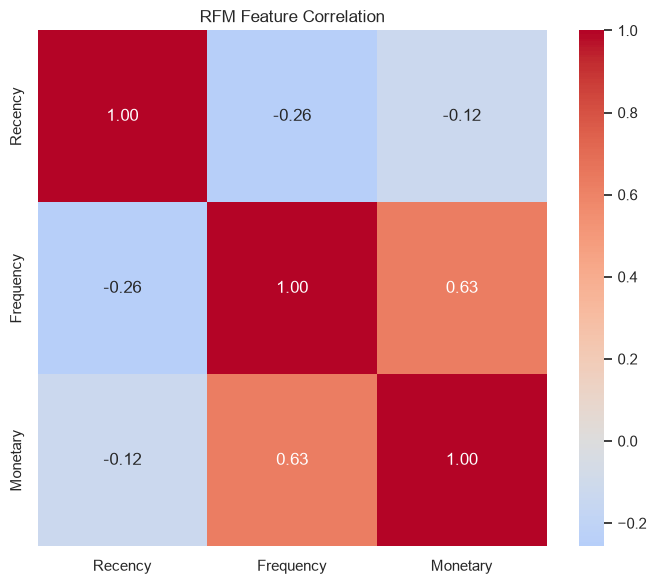

In [33]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    rfm[
        [
            "Recency",
            "Frequency",
            "Monetary"
        ]
    ].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("RFM Feature Correlation")

plt.tight_layout()
plt.show()

<h2>Prepare Data for K-Means</h2>
<h2>Log Transform RFM</h2>

In [34]:
rfm_ml = rfm[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary"
    ]
].copy()

rfm_ml["Recency_Log"] = np.log1p(
    rfm_ml["Recency"]
)

rfm_ml["Frequency_Log"] = np.log1p(
    rfm_ml["Frequency"]
)

rfm_ml["Monetary_Log"] = np.log1p(
    rfm_ml["Monetary"]
)

<h2>Standardize Features</h2>

In [35]:
features = [
    "Recency_Log",
    "Frequency_Log",
    "Monetary_Log"
]

scaler = StandardScaler()

X = scaler.fit_transform(
    rfm_ml[features]
)

print(X.shape)

(5881, 3)


<h2>Determine Optimal Number of Clusters</h2>

In [37]:
inertia = []
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    inertia.append(
        kmeans.inertia_
    )

    silhouette_scores.append(
        silhouette_score(
            X,
            labels
        )
    )

<h2>Elbow Plot</h2>

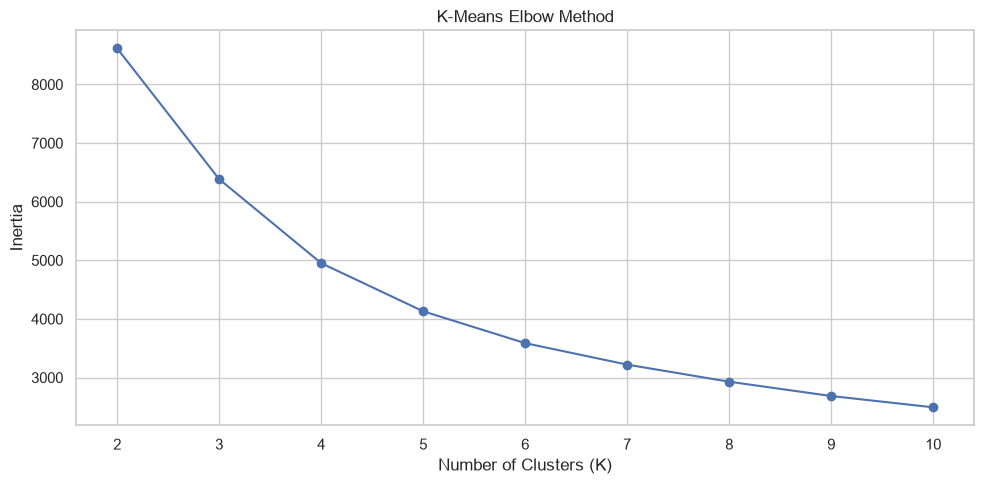

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(
    list(K_range),
    inertia,
    marker="o"
)

plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(list(K_range))

plt.tight_layout()
plt.show()

<h2>Silhouette Score Plot</h2>

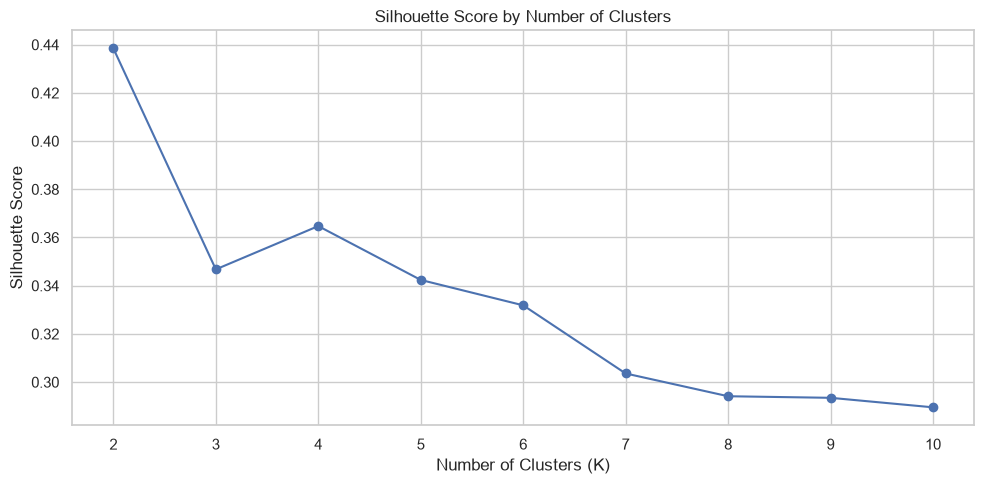

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    list(K_range),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.xticks(list(K_range))

plt.tight_layout()
plt.show()

<h2>Choose K</h2>

In [40]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm_ml["Cluster"] = kmeans.fit_predict(X)

<h2>Cluster Distribution</h2>

In [41]:
rfm_ml["Cluster"].value_counts().sort_index()

Cluster
0    1464
1    1979
2    1251
3    1187
Name: count, dtype: int64

<h2>Cluster Profiles</h2>

In [43]:
rfm_clustered = rfm.merge(
    rfm_ml[
        [
            "CustomerID",
            "Cluster"
        ]
    ],
    on="CustomerID",
    how="left"
)

In [44]:
cluster_summary = (
    rfm_clustered
    .groupby("Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean"),
        TotalRevenue=("Monetary", "sum")
    )
    .round(2)
)

cluster_summary

,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue
Cluster,,,,,
0,1464,227.95,5.09,"1,965.07","2,876,858.84"
1,1979,395.66,1.38,318.35,"630,021.71"
2,1251,28.36,3.04,854.34,"1,068,774.24"
3,1187,27.43,19.36,"10,782.77","12,799,149.48"


<h2>Sort Clusters by Value</h2>

In [45]:
cluster_summary.sort_values(
    "AvgMonetary",
    ascending=False
)

,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue
Cluster,,,,,
3,1187,27.43,19.36,"10,782.77","12,799,149.48"
0,1464,227.95,5.09,"1,965.07","2,876,858.84"
2,1251,28.36,3.04,854.34,"1,068,774.24"
1,1979,395.66,1.38,318.35,"630,021.71"


<h2>Create Business Labels for Clusters</h2>

For example, based on your actual cluster profiles, you might end up with:

Cluster 0 → High Value
Cluster 1 → Low Value
Cluster 2 → Frequent Customers
Cluster 3 → At Risk

In [46]:
cluster_summary

,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue
Cluster,,,,,
0,1464,227.95,5.09,"1,965.07","2,876,858.84"
1,1979,395.66,1.38,318.35,"630,021.71"
2,1251,28.36,3.04,854.34,"1,068,774.24"
3,1187,27.43,19.36,"10,782.77","12,799,149.48"


In [47]:
rfm_clustered["ClusterLabel"] = (
    "Cluster " +
    rfm_clustered["Cluster"].astype(str)
)

<h2>Compare Rule-Based vs K-Means</h2>
Create

In [48]:
comparison = (
    rfm_clustered
    .groupby(
        [
            "Segment",
            "Cluster"
        ]
    )
    .size()
    .reset_index(
        name="Customers"
    )
)

comparison

,Segment,Cluster,Customers
0,At Risk,0,540
1,At Risk,1,187
2,Big Spenders,0,115
3,Big Spenders,3,14
4,Champions,0,99
5,Champions,2,136
6,Champions,3,1062
7,Lost Customers,0,30
8,Lost Customers,1,850
9,Loyal Customers,0,418


Pivot

In [49]:
comparison_matrix = comparison.pivot(
    index="Segment",
    columns="Cluster",
    values="Customers"
).fillna(0)

comparison_matrix

Cluster,0,1,2,3
Segment,,,,
At Risk,540.00,187.00,0.00,0.00
Big Spenders,115.00,0.00,0.00,14.00
Champions,99.00,0.00,136.00,"1,062.00"
Lost Customers,30.00,850.00,0.00,0.00
Loyal Customers,418.00,4.00,173.00,106.00
New Customers,0.00,1.00,54.00,0.00
Others,247.00,922.00,209.00,0.00
Potential Loyalists,15.00,15.00,679.00,5.00


Heatmap

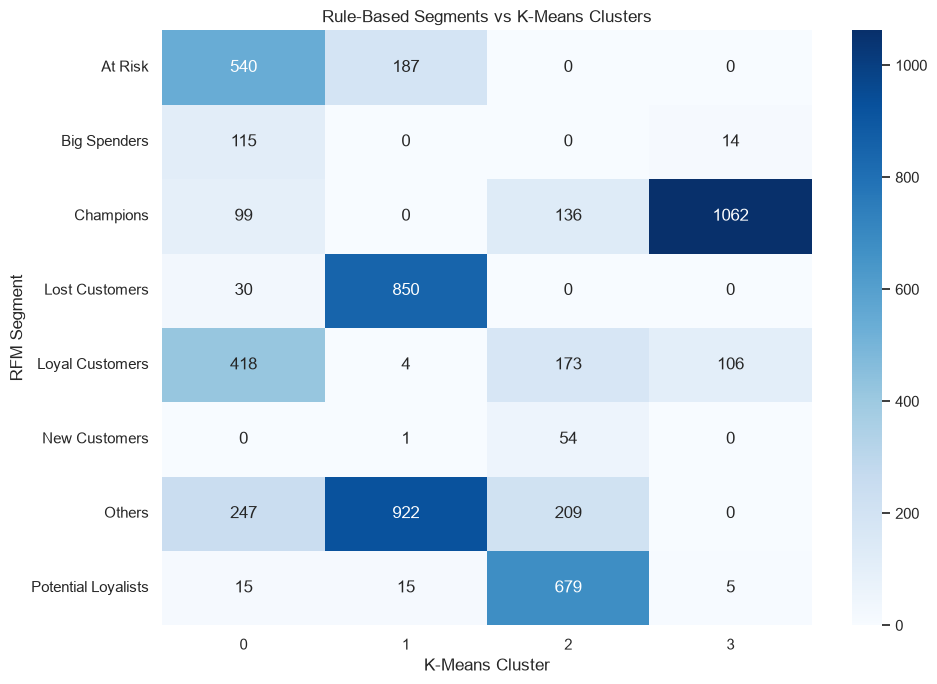

In [50]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    comparison_matrix,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title(
    "Rule-Based Segments vs K-Means Clusters"
)

plt.xlabel("K-Means Cluster")
plt.ylabel("RFM Segment")

plt.tight_layout()
plt.show()

<h2>Visualize Customer Clusters</h2>
Frequency vs Monetary

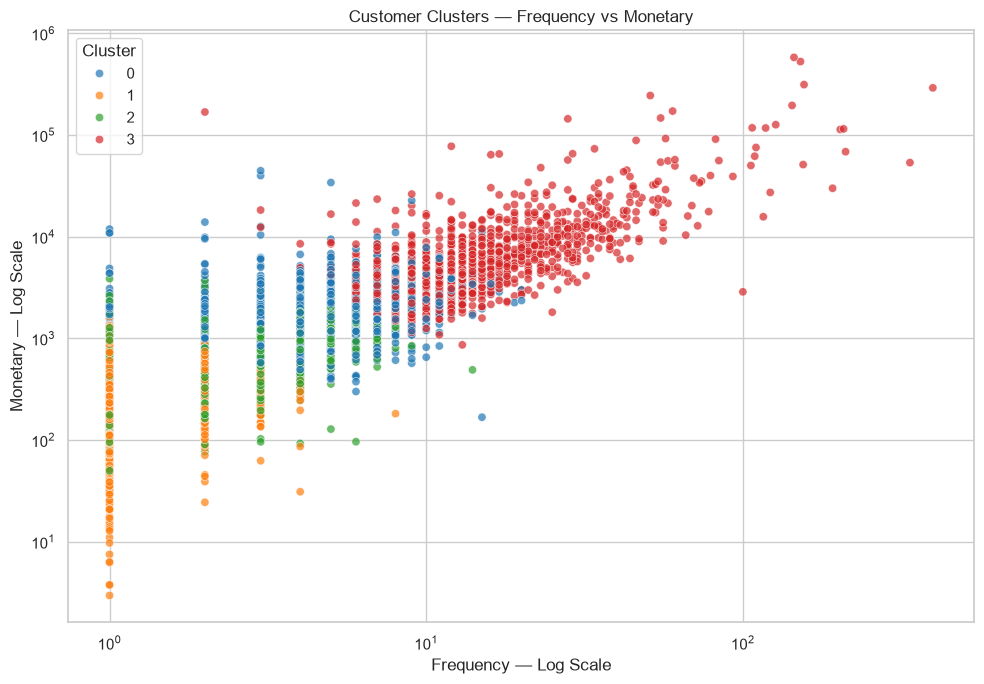

In [51]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm_clustered,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="tab10",
    alpha=0.7
)

plt.xscale("log")
plt.yscale("log")

plt.title(
    "Customer Clusters — Frequency vs Monetary"
)

plt.xlabel("Frequency — Log Scale")
plt.ylabel("Monetary — Log Scale")

plt.tight_layout()
plt.show()

Recency vs Monetary

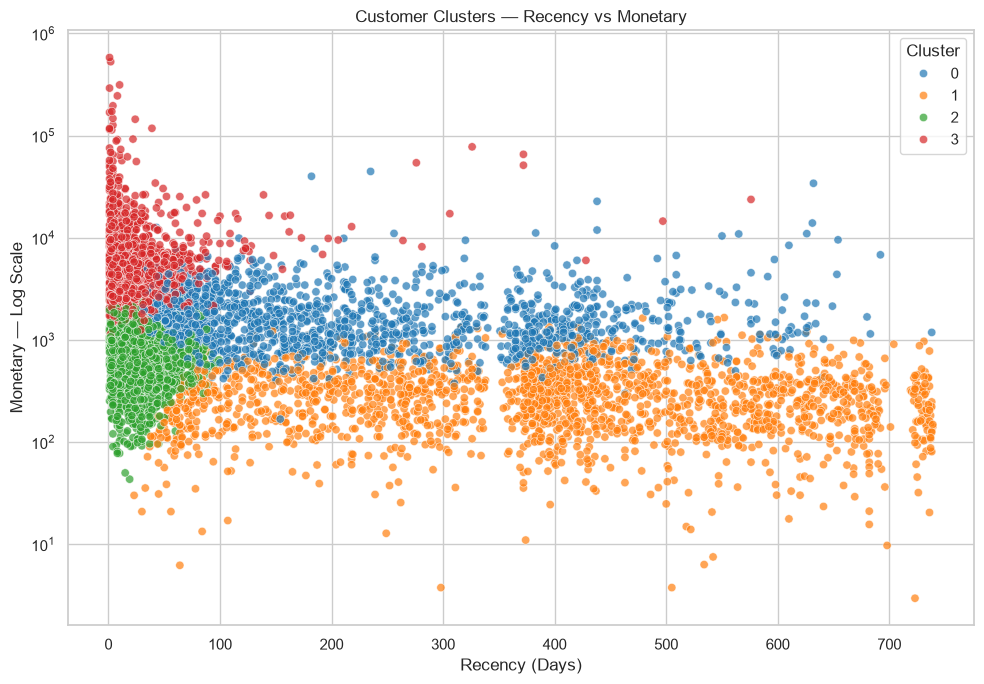

In [52]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=rfm_clustered,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="tab10",
    alpha=0.7
)

plt.yscale("log")

plt.title(
    "Customer Clusters — Recency vs Monetary"
)

plt.xlabel("Recency (Days)")
plt.ylabel("Monetary — Log Scale")

plt.tight_layout()
plt.show()

<h2>Cluster Profiles Visualization</h2>

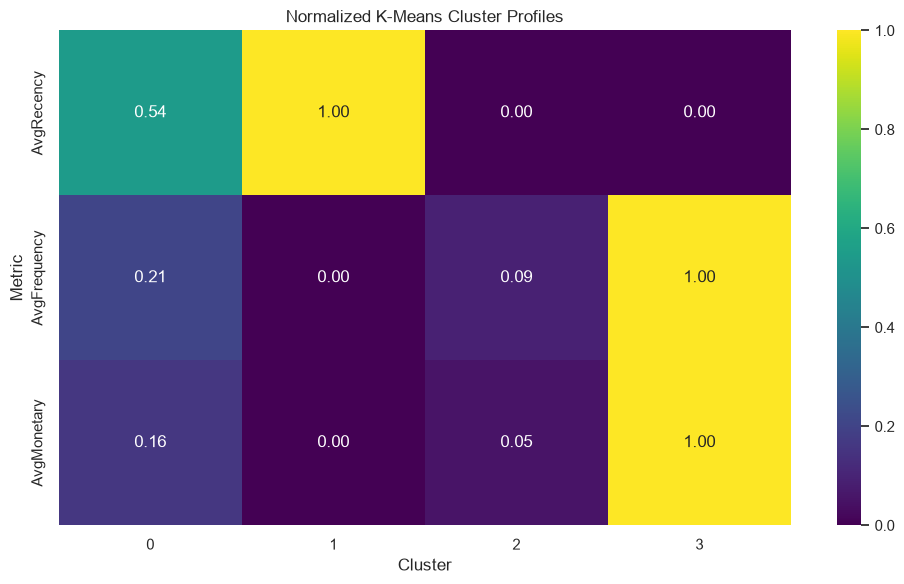

In [53]:
cluster_profile_plot = (
    cluster_summary[
        [
            "AvgRecency",
            "AvgFrequency",
            "AvgMonetary"
        ]
    ]
    .copy()
)

cluster_profile_normalized = (
    cluster_profile_plot -
    cluster_profile_plot.min()
) / (
    cluster_profile_plot.max() -
    cluster_profile_plot.min()
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_profile_normalized.T,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title(
    "Normalized K-Means Cluster Profiles"
)

plt.xlabel("Cluster")
plt.ylabel("Metric")

plt.tight_layout()
plt.show()

<h2>Find the Most Valuable Customers</h2>

In [54]:
top_customers = (
    rfm_clustered
    .sort_values(
        [
            "Monetary",
            "Frequency"
        ],
        ascending=False
    )
    .head(25)
)

top_customers[
    [
        "CustomerID",
        "Recency",
        "Frequency",
        "Monetary",
        "RFM_Score",
        "Segment",
        "Cluster"
    ]
]

,CustomerID,Recency,Frequency,Monetary,RFM_Score,Segment,Cluster
5695,"18,102.00",1,145,"580,987.04",555,Champions,3
2279,"14,646.00",2,152,"528,602.52",555,Champions,3
1791,"14,156.00",10,156,"313,437.62",555,Champions,3
2541,"14,911.00",1,398,"291,420.81",555,Champions,3
5053,"17,450.00",8,51,"244,784.25",555,Champions,3
1332,"13,694.00",4,143,"195,640.69",555,Champions,3
5112,"17,511.00",3,60,"172,132.87",555,Champions,3
4064,"16,446.00",1,2,"168,472.50",525,Potential Loyalists,3
4298,"16,684.00",4,55,"147,142.77",555,Champions,3
68,"12,415.00",24,28,"144,458.37",455,Champions,3


<h2>Customer Segment Revenue Share</h2>

In [55]:
segment_revenue_share = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

segment_revenue_share

Segment
Champions             11,859,591.49
Loyal Customers        1,856,667.02
Big Spenders           1,038,858.56
Potential Loyalists      815,892.04
At Risk                  756,478.08
Others                   720,802.42
Lost Customers           307,088.32
New Customers             19,426.32
Name: Monetary, dtype: float64

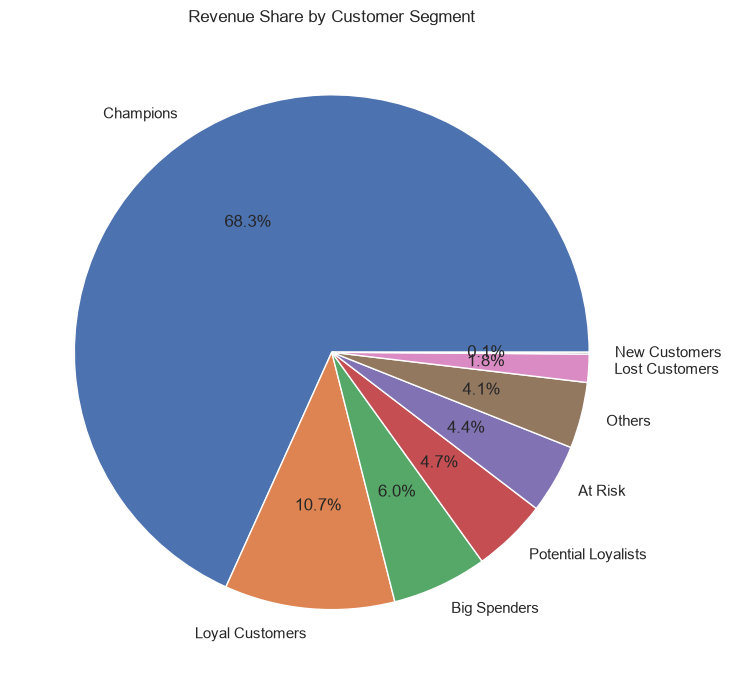

In [56]:
plt.figure(figsize=(10, 7))

plt.pie(
    segment_revenue_share.values,
    labels=segment_revenue_share.index,
    autopct="%1.1f%%"
)

plt.title("Revenue Share by Customer Segment")

plt.tight_layout()
plt.show()

<h2>Save RFM Dataset</h2>

In [57]:
rfm_path = (
    PROCESSED_DATA_DIR /
    "customer_rfm.csv"
)

rfm_clustered.to_csv(
    rfm_path,
    index=False
)

print(
    f"Saved RFM dataset to:\n{rfm_path}"
)

Saved RFM dataset to:
/Users/karthikeyanj/Desktop/projects/E-Commerce-Life-Cycle-Analysis/data/processed/customer_rfm.csv


<h2>Save Segment Summary</h2>

In [58]:
segment_summary.to_csv(
    REPORTS_DIR /
    "customer_segment_summary.csv"
)

<h2>Save K-Means Summary</h2>

In [59]:
cluster_summary.to_csv(
    REPORTS_DIR /
    "kmeans_cluster_summary.csv"
)

<h2>Save Model Evaluation</h2>

In [60]:
model_evaluation = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia,
    "SilhouetteScore": silhouette_scores
})

model_evaluation

,K,Inertia,SilhouetteScore
0,2,"8,615.21",0.44
1,3,"6,384.17",0.35
2,4,"4,951.52",0.36
3,5,"4,130.32",0.34
4,6,"3,586.84",0.33
5,7,"3,220.63",0.30
6,8,"2,928.95",0.29
7,9,"2,685.00",0.29
8,10,"2,492.08",0.29


In [61]:
model_evaluation.to_csv(
    REPORTS_DIR /
    "kmeans_evaluation.csv",
    index=False
)

<h2>Final RFM Validation</h2>

In [62]:
print("=" * 60)
print("RFM ANALYSIS COMPLETE")
print("=" * 60)

print(
    f"Identified customers: "
    f"{len(rfm):,}"
)

print(
    f"Average recency: "
    f"{rfm['Recency'].mean():.1f} days"
)

print(
    f"Average frequency: "
    f"{rfm['Frequency'].mean():.2f} orders"
)

print(
    f"Average monetary value: "
    f"£{rfm['Monetary'].mean():,.2f}"
)

print("\nCustomer segments:")
print(
    rfm["Segment"]
    .value_counts()
)

print("\nK-Means clusters:")
print(
    rfm_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

RFM ANALYSIS COMPLETE
Identified customers: 5,881
Average recency: 201.5 days
Average frequency: 6.29 orders
Average monetary value: £2,954.40

Customer segments:
Segment
Others                 1378
Champions              1297
Lost Customers          880
At Risk                 727
Potential Loyalists     714
Loyal Customers         701
Big Spenders            129
New Customers            55
Name: count, dtype: int64

K-Means clusters:
Cluster
0    1464
1    1979
2    1251
3    1187
Name: count, dtype: int64


              TRANSACTIONS
                   │
                   ▼
         Remove anonymous IDs
                   │
                   ▼
             CUSTOMER DATA
                   │
          ┌────────┼────────┐
          ▼        ▼        ▼
       Recency  Frequency Monetary
          │        │        │
          └────────┼────────┘
                   ▼
              RFM SCORE
                   │
                   ▼
        RULE-BASED SEGMENTS
                   │
       ┌───────────┼────────────┐
       ▼           ▼            ▼
   Champions    Loyal       At Risk
                   │
                   ▼
             K-MEANS ML
                   │
                   ▼
          CLUSTER PROFILES
                   │
                   ▼
        BUSINESS INTERPRETATION